In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/keneepatel/nscc-geojson/Nova_Scotia_Community_Clusters_20260306.geojson
/kaggle/input/datasets/keneepatel/nscc-census-population/Nova_Scotia_Community_Clusters_Census_Population_20260306.csv
/kaggle/input/datasets/keneepatel/ns-health-zones/Nova_Scotia_Health_Authority_Management_Zones_20260307.geojson
/kaggle/input/datasets/keneepatel/nsc-cluster/Nova_Scotia_Community_Clusters_20260306.csv
/kaggle/input/datasets/keneepatel/hospitals-geojson/Hospitals_20260306.geojson
/kaggle/input/datasets/keneepatel/ns-civic-address-file-geojson/Nova_Scotia_Civic_Address_File_(NSCAF)_-_Community_Boundaries_20260306.geojson
/kaggle/input/datasets/keneepatel/hospitals-novascotia/Hospitals.csv
/kaggle/input/datasets/keneepatel/number-of-ehs-responses/Emergency_Health_Services_20260307.csv


In [3]:
# Imports
import geopandas as gpd
from shapely.geometry import Point

In [4]:
communities = gpd.read_file('/kaggle/input/datasets/keneepatel/ns-civic-address-file-geojson/Nova_Scotia_Civic_Address_File_(NSCAF)_-_Community_Boundaries_20260306.geojson')
communities.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2312 entries, 0 to 2311
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   :id          2312 non-null   object             
 1   :version     2312 non-null   object             
 2   :created_at  2312 non-null   datetime64[ms, UTC]
 3   :updated_at  2312 non-null   datetime64[ms, UTC]
 4   objectid     2312 non-null   object             
 5   gsa_key      2312 non-null   object             
 6   gsa_code     2312 non-null   object             
 7   gsa_name     2312 non-null   object             
 8   co_code      2312 non-null   object             
 9   mun_id       2312 non-null   object             
 10  edit_v       2312 non-null   object             
 11  retired      2312 non-null   object             
 12  verified     2312 non-null   object             
 13  locked       2312 non-null   object             
 14  mun_code     231

In [5]:
communities.head()

,:id,:version,:created_at,:updated_at,objectid,gsa_key,gsa_code,gsa_name,co_code,mun_id,edit_v,retired,verified,locked,mun_code,geometry
0,row-dwuw_zvar.ntvn,rv-giru-ect8-3hxc,2026-03-05 12:05:37.373000+00:00,2026-03-05 12:05:37.373000+00:00,133818,999,GCANJB,Garden of Eden Barrens,GU,0,0,N,Y,N,SM,"MULTIPOLYGON (((-62.31344 45.35003, -62.24603 ..."
1,row-rhdx~f6d6.rr85,rv-y8xw.i529-3ta6,2026-03-05 12:05:37.373000+00:00,2026-03-05 12:05:37.373000+00:00,134080,2710,GCBVIN,McCormack Lake,CO,0,0,N,N,N,CO,"MULTIPOLYGON (((-63.88306 45.54359, -63.81508 ..."
2,row-kfk7.jmgf-rsxk,rv-42gi-g6it_yk3x,2026-03-05 12:05:37.373000+00:00,2026-03-05 12:05:37.373000+00:00,137069,3263,GCANNO,George Island,GU,0,0,N,N,N,GU,"MULTIPOLYGON (((-60.93759 45.35792, -60.93736 ..."
3,row-s5tu-rx9j-4p2c,rv-8vfu~z5iu.bxs4,2026-03-05 12:05:37.373000+00:00,2026-03-05 12:05:37.373000+00:00,136776,2273,GCBAMO,Mud Island,YA,0,0,N,Y,N,AY,"MULTIPOLYGON (((-66.0197 43.53058, -65.92959 4..."
4,row-7fx5~xh47~kmmw,rv-side_fssk-ur5a,2026-03-05 12:05:37.373000+00:00,2026-03-05 12:05:37.373000+00:00,138131,3197,GCAYPP,McNabs Island,HX,153,0,N,Y,N,HX,"MULTIPOLYGON (((-63.5432 44.62786, -63.52931 4..."


In [6]:
communities.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [7]:
# 1. Project to metric CRS
communities_proj = communities.to_crs(epsg=3347)

# 2. Compute centroids
communities_proj["centroid"] = communities_proj.geometry.centroid

# 3. Convert centroid geometry back to lat/lon
centroids = gpd.GeoSeries(communities_proj["centroid"], crs=3347).to_crs(epsg=4326)

# 4. Extract lat/lon
communities_proj["lat"] = centroids.y
communities_proj["lon"] = centroids.x

# 5. Keep useful columns
communities_points = communities_proj[["gsa_name", "lat", "lon"]]

# rename column
communities_points = communities_points.rename(columns={"gsa_name": "community"})

In [8]:
communities_points.head()

,community,lat,lon
0,Garden of Eden Barrens,45.333679,-62.247957
1,McCormack Lake,45.531405,-63.847227
2,George Island,45.342261,-60.953004
3,Mud Island,43.487911,-65.985400
4,McNabs Island,44.601835,-63.524616


In [9]:
communities_points.describe()

,lat,lon
count,2312.000000,2312.000000
mean,45.145564,-63.341850
std,0.729677,1.729675
min,43.406767,-66.365859
25%,44.617755,-64.678913
50%,45.191787,-63.584632
75%,45.669020,-61.835687
max,47.181759,-59.777710


In [10]:
hospitals = gpd.read_file('/kaggle/input/datasets/keneepatel/hospitals-geojson/Hospitals_20260306.geojson')
hospitals.head()

,:id,:version,:created_at,:updated_at,facility,address,town,county,type,geometry
0,row-bzbe.7vuk~becm,rv-564h_q53z_2fmb,2025-04-05 11:14:13.965000+00:00,2025-04-05 11:14:13.965000+00:00,Cape Breton Regional Hospital,1482 George Street,Sydney,Cape Breton,Regional,POINT (-60.17413 46.11302)
1,row-qqbg.bpwd~gbd9,rv-iq5z-7thx-8bcm,2025-04-05 11:14:13.965000+00:00,2025-04-05 11:14:13.965000+00:00,Northside General Hospital,520 Purves Street,North Sydney,Cape Breton,Community,POINT (-60.23555 46.21821)
2,row-x8rz-nq8v.kkce,rv-pigc~xrmf~iey6,2025-04-05 11:14:13.965000+00:00,2025-04-05 11:14:13.965000+00:00,Victoria County Memorial Hospital,30 Old Margaree Road,Baddeck,Victoria,Community,POINT (-60.75603 46.10026)
3,row-b2ct.mpbw~9y2s,rv-dxgm~49x8~99us,2025-04-05 11:14:13.965000+00:00,2025-04-05 11:14:13.965000+00:00,Inverness Consolidated Memorial Hospital,39 James Street,Inverness,Inverness,Community,POINT (-61.30484 46.22697)
4,row-aimp.ih3i~2qi3,rv-zrfb-jnjt~rb5q,2025-04-05 11:14:13.965000+00:00,2025-04-05 11:14:13.965000+00:00,Aberdeen Hospital,835 East River Road,New Glasgow,Pictou,Regional,POINT (-62.64327 45.57298)


In [11]:
hospitals["lat"] = hospitals.geometry.y
hospitals["lon"] = hospitals.geometry.x

hospital_points = hospitals[["facility", "lat", "lon"]]
hospital_points.head()

,facility,lat,lon
0,Cape Breton Regional Hospital,46.113016,-60.174134
1,Northside General Hospital,46.218208,-60.235552
2,Victoria County Memorial Hospital,46.100264,-60.756029
3,Inverness Consolidated Memorial Hospital,46.226968,-61.304843
4,Aberdeen Hospital,45.572976,-62.643268


In [12]:
hospital_points.describe()

,lat,lon
count,48.000000,48.000000
mean,45.216320,-63.132550
std,0.694581,1.663429
min,43.749990,-66.121569
25%,44.704485,-64.337900
50%,45.085134,-63.581118
75%,45.657003,-61.863119
max,46.810570,-59.938573


In [13]:
communities_geo = gpd.GeoDataFrame(
    communities_points,
    geometry=gpd.points_from_xy(communities_points.lon, communities_points.lat),
    crs="EPSG:4326"
)

In [14]:
hospital_geo = gpd.GeoDataFrame(
    hospital_points,
    geometry=gpd.points_from_xy(hospital_points.lon, hospital_points.lat),
    crs="EPSG:4326"
)

In [15]:
communities_geo = communities_geo.to_crs(epsg=3347)
hospital_geo = hospital_geo.to_crs(epsg=3347)

In [16]:
nearest = gpd.sjoin_nearest(
    communities_geo,
    hospital_geo,
    how="left",
    distance_col="distance_m"
)

In [17]:
nearest["distance_km"] = nearest["distance_m"] / 1000
nearest.head()

,community,lat_left,lon_left,geometry,index_right,facility,lat_right,lon_right,distance_m,distance_km
0,Garden of Eden Barrens,45.333679,-62.247957,POINT (8474190.907 1557550.341),13,St. Mary’s Memorial Hospital,45.146936,-61.981780,29932.976376,29.932976
1,McCormack Lake,45.531405,-63.847227,POINT (8350180.788 1521988.848),34,All Saints Springhill Hospital,45.650499,-64.051598,21027.913758,21.027914
2,George Island,45.342261,-60.953004,POINT (8565397.341 1605641.749),10,Eastern Memorial Hospital,45.332628,-60.984005,2697.264900,2.697265
3,Mud Island,43.487911,-65.985400,POINT (8287323.402 1239614.845),21,Yarmouth Regional Hospital,43.850524,-66.121569,42765.192800,42.765193
4,McNabs Island,44.601835,-63.524616,POINT (8418573.311 1438137.972),39,The Nova Scotia Hospital,44.652052,-63.548885,6017.081778,6.017082


In [18]:
results = nearest[[
    "community",
    "facility",
    "distance_km"
]]

In [19]:
results = results.rename(columns={"facility": "nearest_hospital"})

In [20]:
results.head()

,community,nearest_hospital,distance_km
0,Garden of Eden Barrens,St. Mary’s Memorial Hospital,29.932976
1,McCormack Lake,All Saints Springhill Hospital,21.027914
2,George Island,Eastern Memorial Hospital,2.697265
3,Mud Island,Yarmouth Regional Hospital,42.765193
4,McNabs Island,The Nova Scotia Hospital,6.017082


In [21]:
results["distance_km"].describe()

count    2312.000000
mean       17.469615
std        10.421604
min         0.106644
25%         9.166193
50%        15.941700
75%        24.268851
max        52.104891
Name: distance_km, dtype: float64

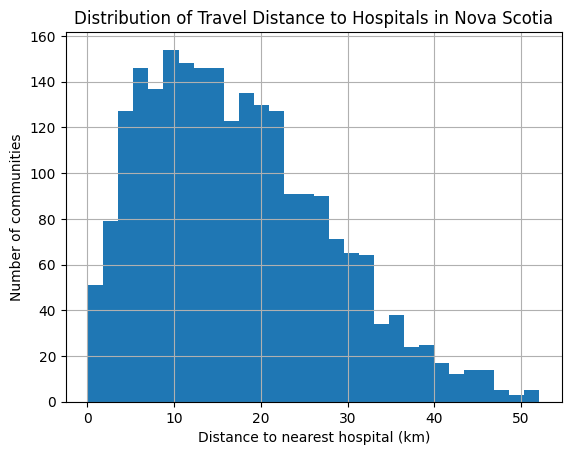

In [22]:
import matplotlib.pyplot as plt

results["distance_km"].hist(bins=30)
plt.xlabel("Distance to nearest hospital (km)")
plt.ylabel("Number of communities")
plt.title("Distribution of Travel Distance to Hospitals in Nova Scotia")
plt.savefig("/kaggle/working/hist_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
bins = [0,10,20,30,50,100]
labels = ["<10 km","10-20 km","20-30 km","30-50 km","50+ km"]

results["distance_category"] = pd.cut(results["distance_km"], bins=bins, labels=labels)

In [24]:
results["distance_category"].value_counts()

distance_category
10-20 km    806
<10 km      651
20-30 km    549
30-50 km    300
50+ km        6
Name: count, dtype: int64

In [25]:
(results["distance_km"] > 30).sum()

np.int64(306)

In [26]:
(results["distance_km"] > 30).mean()

np.float64(0.1323529411764706)

In [27]:
results.sort_values("distance_km", ascending=False).head(10)

,community,nearest_hospital,distance_km,distance_category
1487,Framboise Intervale,Cape Breton Regional Hospital,52.104891,50+ km
600,Freeport,Yarmouth Regional Hospital,51.519354,50+ km
614,Central Grove,Digby General Hospital,51.275495,50+ km
1020,Kejimkujik National Park of Canada,Annapolis Community Health Centre,50.831702,50+ km
592,Seal Island,Yarmouth Regional Hospital,50.411111,50+ km
867,McCoys Ridge,Roseway Hospital,50.345651,50+ km
597,Westport,Yarmouth Regional Hospital,49.950066,30-50 km
866,Alder Plains,Roseway Hospital,48.959741,30-50 km
1201,Comeauville,Digby General Hospital,47.597954,30-50 km
482,Barrio Lake,Yarmouth Regional Hospital,47.300430,30-50 km


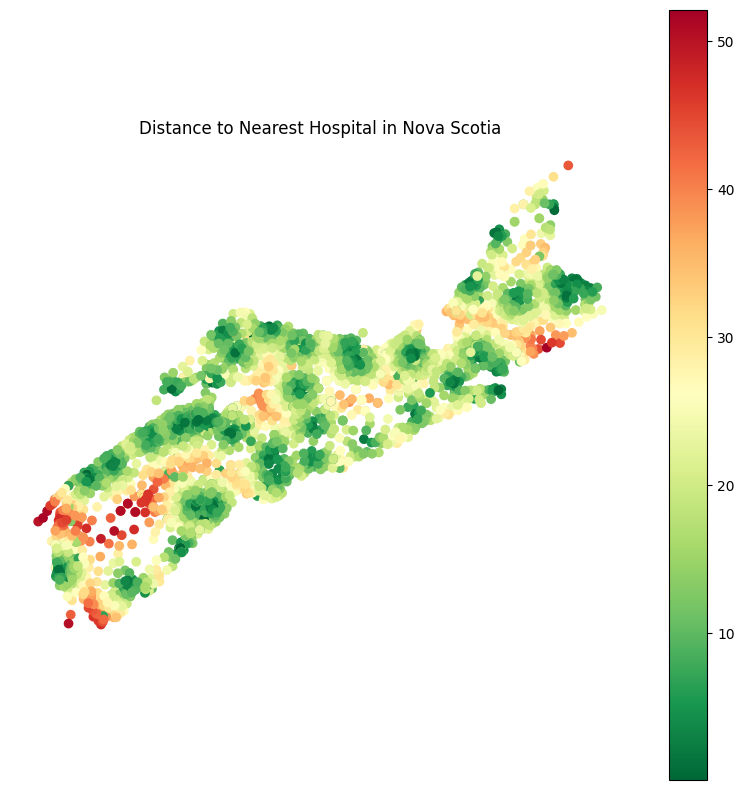

In [28]:
map_data = communities_geo.merge(
    results,
    left_on="community",
    right_on="community"
)
map_data = map_data.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(10,10))

map_data.plot(
    column="distance_km",
    cmap="RdYlGn_r",   # green = close, red = far
    legend=True,
    ax=ax
)

ax.set_title("Distance to Nearest Hospital in Nova Scotia")
ax.axis("off")

plt.savefig("/kaggle/working/distance_plot.png", dpi=300, bbox_inches="tight")
plt.show()


In [29]:
zones = gpd.read_file('/kaggle/input/datasets/keneepatel/ns-health-zones/Nova_Scotia_Health_Authority_Management_Zones_20260307.geojson')
zones.head()

,:id,:version,:created_at,:updated_at,zone,zoneid,name,shape_leng,shape_area,geometry
0,row-mum9~yr9q~xpr6,rv-2u85.shsx~4tcu,2025-04-05 11:06:29.632000+00:00,2025-04-05 11:06:29.632000+00:00,Zone 1 - Western,01,Western,939705.657029,21251166435.6,"MULTIPOLYGON (((-64.41005 44.91392, -64.4177 4..."
1,row-smf9_i9s8-z6ru,rv-bjhs.ychr_7r9c,2025-04-05 11:06:29.632000+00:00,2025-04-05 11:06:29.632000+00:00,Zone 2 - Northern,02,Northern,920339.075806,13454096221.1,"MULTIPOLYGON (((-64.00401 45.99877, -64.00323 ..."
2,row-jusx~z3cj~wbbb,rv-7krw_27ms.h5z8,2025-04-05 11:06:29.632000+00:00,2025-04-05 11:06:29.632000+00:00,Zone 3 - Eastern,03,Eastern,1260219.00282,19174147955.7,"MULTIPOLYGON (((-62.17509 45.57963, -62.17668 ..."
3,row-fxas~sxek~7dzp,rv-jyie.zc5k.9hrd,2025-04-05 11:06:29.632000+00:00,2025-04-05 11:06:29.632000+00:00,Zone 4 - Central,04,Central,662867.734117,8444361194.19,"MULTIPOLYGON (((-62.70045 45.26932, -62.69432 ..."


In [30]:
zones = zones.to_crs(epsg=3347)
communities_with_zone = gpd.sjoin(
    communities_geo,
    zones[["zone","geometry"]],
    how="left",
    predicate="within"
)
communities_with_zone.head()

,community,lat,lon,geometry,index_right,zone
0,Garden of Eden Barrens,45.333679,-62.247957,POINT (8474190.907 1557550.341),2,Zone 3 - Eastern
1,McCormack Lake,45.531405,-63.847227,POINT (8350180.788 1521988.848),1,Zone 2 - Northern
2,George Island,45.342261,-60.953004,POINT (8565397.341 1605641.749),2,Zone 3 - Eastern
3,Mud Island,43.487911,-65.985400,POINT (8287323.402 1239614.845),0,Zone 1 - Western
4,McNabs Island,44.601835,-63.524616,POINT (8418573.311 1438137.972),3,Zone 4 - Central


In [31]:
communities_with_zone["zone"].value_counts()

zone
Zone 1 - Western     834
Zone 3 - Eastern     693
Zone 2 - Northern    535
Zone 4 - Central     250
Name: count, dtype: int64

In [32]:
communities_with_zone.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 2312 entries, 0 to 2311
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   community    2312 non-null   object  
 1   lat          2312 non-null   float64 
 2   lon          2312 non-null   float64 
 3   geometry     2312 non-null   geometry
 4   index_right  2312 non-null   int64   
 5   zone         2312 non-null   object  
dtypes: float64(2), geometry(1), int64(1), object(2)
memory usage: 126.4+ KB


In [33]:
results_with_zone = nearest.merge(
    communities_with_zone[["community", "zone"]],
    on="community",
    how="left"
)
distance_by_zone = results_with_zone.groupby("zone")["distance_km"].mean().reset_index()
distance_by_zone.sort_values("distance_km", ascending=False)

,zone,distance_km
0,Zone 1 - Western,18.979235
2,Zone 3 - Eastern,17.618602
1,Zone 2 - Northern,16.238652
3,Zone 4 - Central,15.101349


In [34]:
ehs = pd.read_csv('/kaggle/input/datasets/keneepatel/number-of-ehs-responses/Emergency_Health_Services_20260307.csv')
ehs.head()

,Zone,Hospital,Type,Date,Measure Name,Actual,CTAS
0,Western,Valley Regional Hospital,NaN,2023-12-01,ED Offload Interval,"7,663.915",NaN
1,Western,Yarmouth Regional Hospital,NaN,2023-12-01,ED Offload Interval,"3,571.485",NaN
2,Western,Yarmouth Regional Hospital,NaN,2023-12-01,ED Offload Interval,"5,229.05",NaN
3,Central,Eastern Shore Memorial Hospital,NaN,2023-12-01,ED Offload Interval,12.58,NaN
4,Central,NaN,NaN,2023-12-01,EHS Responses,923,NaN


In [35]:
ehs_responses = ehs[ehs["Measure Name"] == "EHS Responses"]
ehs_responses["Actual"] = (
    ehs_responses["Actual"]
    .astype(str)
    .str.replace(",", "")
    .astype(float)
)
ehs_responses.head()

/tmp/ipykernel_698/1039821372.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ehs_responses["Actual"] = (


,Zone,Hospital,Type,Date,Measure Name,Actual,CTAS
4,Central,NaN,NaN,2023-12-01,EHS Responses,923.0,NaN
5,Central,NaN,NaN,2023-12-01,EHS Responses,3569.0,NaN
6,Eastern,NaN,NaN,2023-12-01,EHS Responses,1697.0,NaN
7,Eastern,NaN,NaN,2023-12-01,EHS Responses,452.0,NaN
47,Western,NaN,NaN,2023-12-01,EHS Responses,563.0,NaN


In [36]:
ehs_zone = (
    ehs_responses
    .groupby("Zone")["Actual"]
    .sum()
    .reset_index()
)
ehs_zone = ehs_zone.rename(columns={
    "Zone": "zone",
    "Actual": "ehs_responses"
})
ehs_zone.head()

,zone,ehs_responses
0,Central,132754.0
1,Eastern,61922.0
2,Northern,67914.0
3,Western,79873.0


In [37]:
distance_by_zone["zone"] = (
    distance_by_zone["zone"]
    .str.replace("Zone 1 - ", "")
    .str.replace("Zone 2 - ", "")
    .str.replace("Zone 3 - ", "")
    .str.replace("Zone 4 - ", "")
)
analysis_df = distance_by_zone.merge(
    ehs_zone,
    on="zone"
)

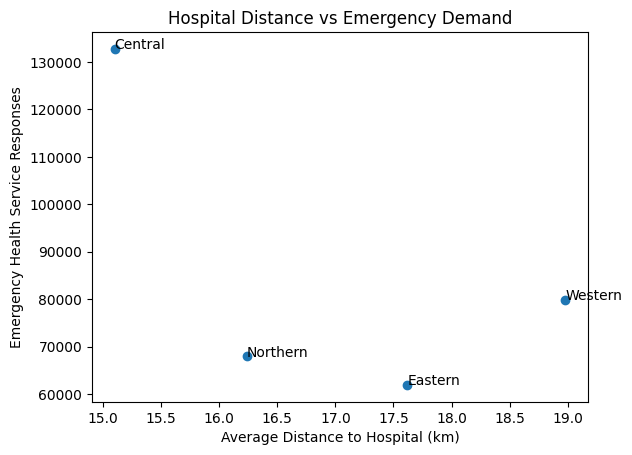

In [38]:
plt.scatter(
    analysis_df["distance_km"],
    analysis_df["ehs_responses"]
)

plt.xlabel("Average Distance to Hospital (km)")
plt.ylabel("Emergency Health Service Responses")
plt.title("Hospital Distance vs Emergency Demand")

for i, row in analysis_df.iterrows():
    plt.text(row["distance_km"], row["ehs_responses"], row["zone"])

plt.savefig("/kaggle/working/ER Demand vs Avg Dist.png", dpi=300, bbox_inches="tight")
plt.show()

In [44]:
pop_data = pd.read_csv('/kaggle/input/datasets/keneepatel/nscc-census-population/Nova_Scotia_Community_Clusters_Census_Population_20260306.csv')
pop_data = pop_data.rename(columns={
    "Zone": "zone",
    "Community Cluster": "community",
    "Population After Weighing": "population"
})
pop_data.head()


,Census Year,zone,ZoneID,Community Health Network,NetworkID,community,ClusterID,Population Un-Weighted,Population Weight,population
0,2011,ZONE 1: WESTERN,1,Annapolis and Kings Community Health Network,103,Annapolis Royal,10308,"5,833",1.0000,"5,833"
1,2011,ZONE 1: WESTERN,1,Annapolis and Kings Community Health Network,103,Berwick,10309,"13,903",0.9888,"13,747"
2,2011,ZONE 1: WESTERN,1,Annapolis and Kings Community Health Network,103,Kentville,10310,"23,937",1.0000,"23,937"
3,2011,ZONE 1: WESTERN,1,Annapolis and Kings Community Health Network,103,Middleton,10311,"21,668",0.9778,"21,187"
4,2011,ZONE 1: WESTERN,1,Annapolis and Kings Community Health Network,103,Wolfville,10312,"14,200",1.0000,"14,200"


In [45]:
pop_data["population"] = (
    pop_data["population"]
    .astype(str)
    .str.replace(",", "")
    .astype(float)
)
pop_data[["community","zone","population"]].head()

,community,zone,population
0,Annapolis Royal,ZONE 1: WESTERN,5833.0
1,Berwick,ZONE 1: WESTERN,13747.0
2,Kentville,ZONE 1: WESTERN,23937.0
3,Middleton,ZONE 1: WESTERN,21187.0
4,Wolfville,ZONE 1: WESTERN,14200.0


In [46]:
pop_data["zone"] = (
    pop_data["zone"]
    .str.replace("ZONE 1: ", "")
    .str.replace("ZONE 2: ", "")
    .str.replace("ZONE 3: ", "")
    .str.replace("ZONE 4: ", "")
    .str.title()
)
population_zone = (
    pop_data
    .groupby("zone")["population"]
    .sum()
    .reset_index()
)
population_zone.head()

,zone,population
0,Central,834538.0
1,Eastern,322640.0
2,Northern,298241.0
3,Western,390419.0


In [48]:
analysis_df = analysis_df.merge(
    population_zone,
    on="zone"
)
analysis_df.head()

,zone,distance_km,ehs_responses,population
0,Western,18.979235,79873.0,390419.0
1,Northern,16.238652,67914.0,298241.0
2,Eastern,17.618602,61922.0,322640.0
3,Central,15.101349,132754.0,834538.0


In [49]:
analysis_df["responses_per_10k"] = (
    analysis_df["ehs_responses"] /
    analysis_df["population"]
) * 10000
analysis_df.head()

,zone,distance_km,ehs_responses,population,responses_per_10k
0,Western,18.979235,79873.0,390419.0,2045.827688
1,Northern,16.238652,67914.0,298241.0,2277.151699
2,Eastern,17.618602,61922.0,322640.0,1919.228862
3,Central,15.101349,132754.0,834538.0,1590.748414


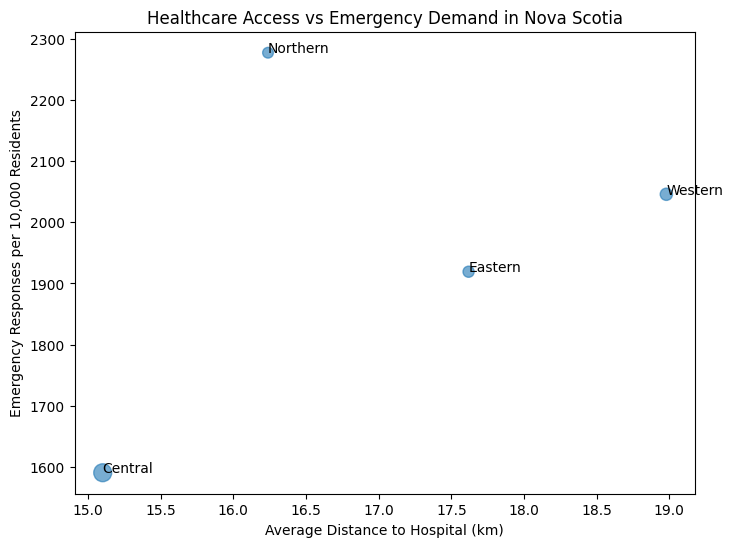

In [54]:
plt.figure(figsize=(8,6))

plt.scatter(
    analysis_df["distance_km"],
    analysis_df["responses_per_10k"],
    s=analysis_df["population"]/5000,
    alpha=0.6
)

plt.xlabel("Average Distance to Hospital (km)")
plt.ylabel("Emergency Responses per 10,000 Residents")
plt.title("Healthcare Access vs Emergency Demand in Nova Scotia")

for i, row in analysis_df.iterrows():
    plt.text(row["distance_km"], row["responses_per_10k"], row["zone"])

plt.savefig("/kaggle/working/ER Demand per 10k Residents vs Avg Dist.png", dpi=300, bbox_inches="tight")
plt.show()

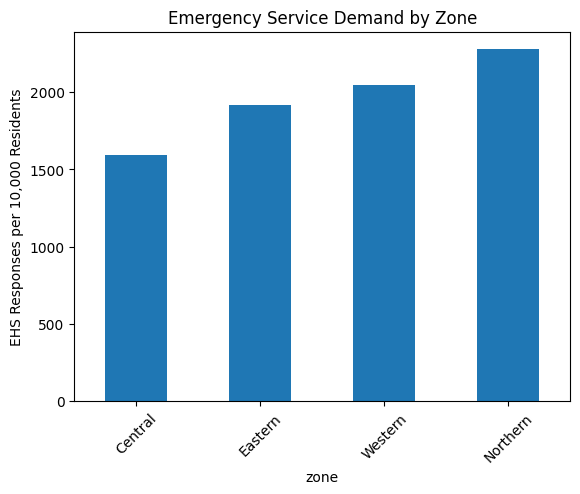

In [52]:
analysis_df.sort_values("responses_per_10k").plot(
    x="zone",
    y="responses_per_10k",
    kind="bar",
    legend=False
)

plt.ylabel("EHS Responses per 10,000 Residents")
plt.title("Emergency Service Demand by Zone")
plt.xticks(rotation=45)
plt.show()

In [53]:
analysis_df["distance_km"].corr(analysis_df["responses_per_10k"])

np.float64(0.41825364415660243)